## Validate models with my own data

In [1]:
# Loading my experiment data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import cognitive_models.preprocessing as cwpre
import cognitive_models.features as cwfeat
import cognitive_models.interpolate as cwinterp
import cognitive_models.pupil_utils as cwpupil
import cognitive_models.gaze_utils as cwgaze
from importlib import reload
reload(cwpupil)
reload(cwgaze)
reload(cwinterp)
reload(cwpre)
reload(cwfeat)

<module 'cognitive_models.features' from 'C:\\Users\\ahebert\\Desktop\\user-adaptive-swarm-interfaces\\research\\cognitive_load_models\\src\\cognitive_models\\features.py'>

In [2]:
NBACK_DATASET_DIR = Path(cwpre.__file__).parents[2] / "datasets" / "NBACK"
TASKS = [1,2,3]
TRIALS = [1,2,3,4]
SUBJECT_EXCLUSION = ["ERK0"]

# First, extract all subjects UID (folder names under NBACK_DATASET_DIR)
subject_uids = [d.name for d in NBACK_DATASET_DIR.iterdir() if d.is_dir()]
subject_uids = [subject_id for subject_id in subject_uids if subject_id not in SUBJECT_EXCLUSION]

# Then, for each subject, load their data
all_eye_df = cwpre.load_nback_dataset(NBACK_DATASET_DIR, subject_uids, TASKS, TRIALS)

Loading subjects:  11%|█         | 1/9 [00:00<00:03,  2.06it/s]

Loading subjects:  22%|██▏       | 2/9 [00:01<00:03,  1.81it/s]

Loading subjects:  44%|████▍     | 4/9 [00:02<00:02,  1.70it/s]

Loading subjects:  56%|█████▌    | 5/9 [00:02<00:02,  1.65it/s]

Loading subjects:  67%|██████▋   | 6/9 [00:03<00:01,  1.61it/s]

Loading subjects: 100%|██████████| 9/9 [00:04<00:00,  1.85it/s]


In [3]:
print(f"Columns in the loaded DataFrame: {all_eye_df.columns.tolist()}")
all_eye_df.head()

Columns in the loaded DataFrame: ['timestamp_sec', 'left_gaze_point_x', 'left_gaze_point_y', 'left_gaze_point_z', 'right_gaze_point_x', 'right_gaze_point_y', 'right_gaze_point_z', 'left_point_screen_x', 'left_point_screen_y', 'right_point_screen_x', 'right_point_screen_y', 'left_validity', 'right_validity', 'left_pupil_diameter', 'right_pupil_diameter', 'left_openness_validity', 'right_openness_validity', 'left_openness', 'right_openness', 'subject_id', 'task_id', 'trial_id', 'nback_level']


,timestamp_sec,left_gaze_point_x,left_gaze_point_y,left_gaze_point_z,right_gaze_point_x,right_gaze_point_y,right_gaze_point_z,left_point_screen_x,left_point_screen_y,right_point_screen_x,...,left_pupil_diameter,right_pupil_diameter,left_openness_validity,right_openness_validity,left_openness,right_openness,subject_id,task_id,trial_id,nback_level
0,0.000,-16.343029,59.31891,746.95795,47.017610,61.719257,747.24457,0.505324,0.470653,0.464930,...,2.473129,2.702225,1.0,1.0,11.053574,11.737167,BEN0,1,1,0
1,0.015,-16.344185,59.33650,746.97296,47.020664,61.731323,747.25775,0.490070,0.505306,0.473532,...,2.578613,2.715958,1.0,1.0,10.601944,11.979462,BEN0,1,1,0
2,0.029,-16.354510,59.36012,746.91120,47.020836,61.741980,747.27160,0.494238,0.496665,0.472929,...,2.558304,2.730728,1.0,1.0,11.155304,11.892044,BEN0,1,1,0
3,0.050,-16.360538,59.36264,746.78880,47.017900,61.746650,747.27136,0.496310,0.497814,0.472496,...,2.542267,2.637650,1.0,1.0,10.797867,11.847229,BEN0,1,1,0
4,0.064,-16.362247,59.36944,746.72784,47.020626,61.749283,747.25560,0.505593,0.496537,0.467977,...,2.565048,2.666122,1.0,1.0,10.634628,11.654297,BEN0,1,1,0


In [14]:
# Select a winow
SUBJECT = "FXXW"
TASK = 1
TRIAL = 1
WINDOW_SIZE = 1500 # datapoints = 60s

window_df = all_eye_df[
    (all_eye_df["subject_id"] == SUBJECT) &
    (all_eye_df["task_id"] == TASK) &
    (all_eye_df["trial_id"] == TRIAL)
].copy()
window_df = window_df.iloc[:WINDOW_SIZE]

# Preprocess the data
preprocessed_window_df, gaze_df, pupil_df, gaps_to_fill_df = cwpre.preprocess_nback_data(window_df, verbose=True)


Identified 13 blinks and 15 low confidence gaps to fill.
Removed 140 low confidence samples from the window.
Removed 56 pupil diameter outliers from the window.
Removed 54 samples due to low confidence and proximity to detected blinks/gaps.


<Axes: xlabel='point_screen_x', ylabel='point_screen_y'>

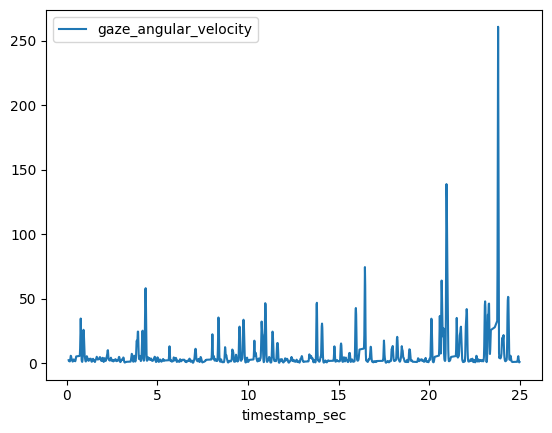

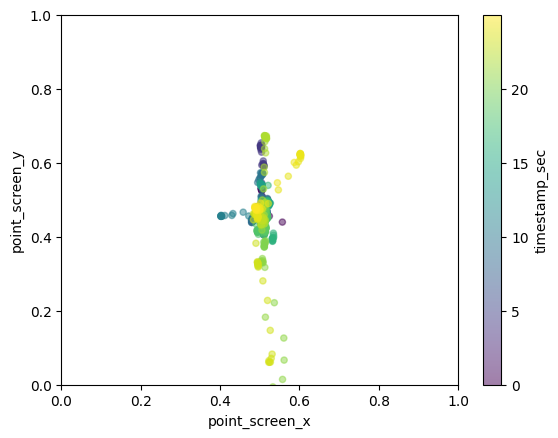

In [15]:
gaze_df.plot(x="timestamp_sec", y="gaze_angular_velocity")

preprocessed_window_df.plot(kind='scatter', x='point_screen_x', y='point_screen_y', alpha=0.5, c='timestamp_sec', cmap='viridis', xlim=(0,1), ylim=(0,1))

Number of fixations: 49
Number of saccades: 49


Text(0.5, 0, 'Time (s)')

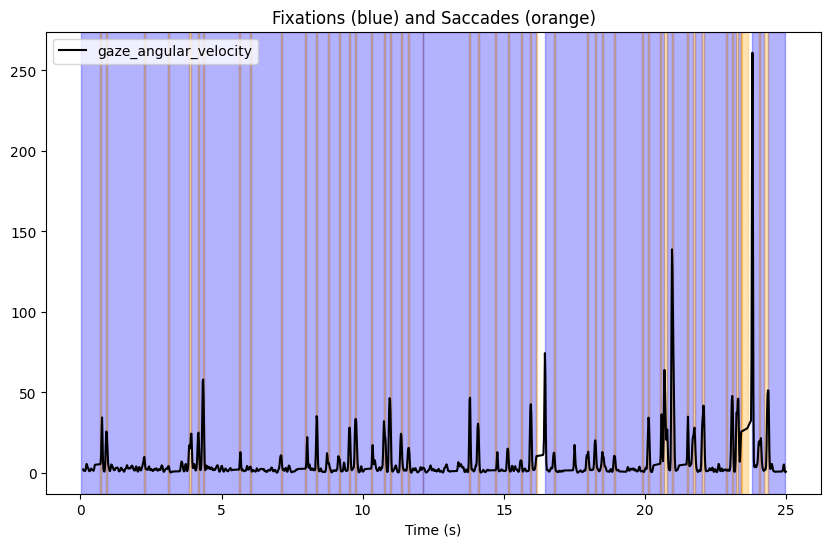

In [25]:
fixations_df, saccades_df = cwgaze.calculate_fixations_saccades_idt(gaze_df, gaps_to_fill_df, idt_duration_threshold=100, idt_dispersion_threshold=0.03, verbose=False)

print(f"Number of fixations: {len(fixations_df)}")
print(f"Number of saccades: {len(saccades_df)}")

# Plot the fixations and saccades
fig, ax = plt.subplots(figsize=(10, 6))
gaze_df.plot(x="timestamp_sec", y="gaze_angular_velocity", ax=ax, color='black')
for _, fixation in fixations_df.iterrows():
    ax.axvspan(fixation['start_timestamp'], fixation['stop_timestamp'], color='blue', alpha=0.3)
for _, saccade in saccades_df.iterrows():
    ax.axvspan(saccade['start_timestamp'], saccade['stop_timestamp'], color='orange', alpha=0.3)
# for _, gap in gaps_to_fill_df[gaps_to_fill_df['duration_ms'] > 100].iterrows():
#     ax.axvspan(gap['start_timestamp'], gap['stop_timestamp'], color='red', alpha=0.3)
ax.set_title("Fixations (blue) and Saccades (orange)")
ax.set_xlabel("Time (s)")

In [ ]:
import tqdm
reload(cwpre)
reload(cwfeat)

NBACK_DATASET_DIR = Path(cwpre.__file__).parents[2] / "datasets" / "NBACK"
TASKS = [1,2,3]
TRIALS = [1,2,3,4]
SUBJECT_EXCLUSION = ["ERK0"]

# First, extract all subjects UID (folder names under NBACK_DATASET_DIR)
subject_uids = [d.name for d in NBACK_DATASET_DIR.iterdir() if d.is_dir()]
subject_uids = [subject_id for subject_id in subject_uids if subject_id not in SUBJECT_EXCLUSION]

# Then, for each subject, load their data
all_eye_df = cwpre.load_nback_dataset(NBACK_DATASET_DIR, subject_uids, TASKS, TRIALS)

all_eye_data_grouped = all_eye_df.groupby(['subject_id', 'task_id', 'trial_id'])
# Extract all window features
Fs = 60
WINDOW_N = 600 # 10 seconds at 60Hz
WINDOW_STEP = 60
SKIP_EDGE_SAMPLES = Fs # first & last second are discarded

skipped_windows = None
skip_window_counter = 0

nback_features_df = pd.DataFrame()
for (subject_id, task_id, trial_id), group_df in tqdm.tqdm(all_eye_data_grouped, desc="Extracting features"):
    feature_rows = []
    group_df = group_df.iloc[SKIP_EDGE_SAMPLES:-SKIP_EDGE_SAMPLES].copy() # Skip edge samples to avoid partial windows at the start and end
    # Preprocess and extract features for the entire task duration
    processed_df, gaze_df, pupil_df, gaps_df = cwpre.preprocess_nback_data(group_df, verbose=False, margins=100 / 1000)
    if processed_df['low_confidence_percentage'].iloc[0] > 30:
        t_start = processed_df['timestamp_sec'].min()
        t_end = processed_df['timestamp_sec'].max()
        print(f"Skipping window [{t_start:.2f}, {t_end:.2f}] due to low confidence percentage of {processed_df['low_confidence_percentage'].iloc[0]:.2f}%")
        continue

    fixations_df, saccades_df = cwgaze.calculate_fixations_saccades_idt(gaze_df, gaps_df, idt_duration_threshold=100, idt_dispersion_threshold=0.03, verbose=False)
    
    # Extract features in sliding windows
    for t in range(0, len(group_df) - WINDOW_N + 1, WINDOW_STEP):
        window_start_timestamp = t / Fs
        window_end_timestamp = (t + WINDOW_N) / Fs

        # Extract features
        window_pupil_df = pupil_df[(pupil_df["timestamp_sec"] >= window_start_timestamp) & (pupil_df["timestamp_sec"] < window_end_timestamp)].copy()
        # Make sure enough data is available in the window
        if len(window_pupil_df) < WINDOW_N * 0.25: # At least 25% of the samples should be present
            print(f"Skipping window [{window_start_timestamp:.2f}, {window_end_timestamp:.2f}] due to insufficient pupil data ({len(window_pupil_df)} samples).")
            skip_window_counter += 1
            continue
        window_gaps_df = gaps_df[(gaps_df["start_timestamp"] >= window_start_timestamp) & (gaps_df["start_timestamp"] < window_end_timestamp)].copy()
        features_dict = cwfeat.extract_window_features(
            window_pupil_df, 
            fixations_df[(fixations_df["start_timestamp"] >= window_start_timestamp) & (fixations_df["start_timestamp"] < window_end_timestamp)],
            saccades_df[(saccades_df["start_timestamp"] >= window_start_timestamp) & (saccades_df["start_timestamp"] < window_end_timestamp)],
            window_gaps_df
        )
        features_dict['subject_id'] = subject_id
        features_dict['task_id'] = task_id
        features_dict['trial_id'] = trial_id
        features_dict['nback_level'] = processed_df['nback_level'].iloc[0]
        feature_rows.append(features_dict)
    
    nback_features_df = pd.concat([nback_features_df, pd.DataFrame(feature_rows)], ignore_index=True)
    # if subject_id > 5:
    #     break

print(f"Extracted features for {len(nback_features_df)} windows.")
print(f"Skipped {skip_window_counter} windows due to low confidence percentage.")

Loading subjects:  11%|█         | 1/9 [00:00<00:03,  2.01it/s]

Loading subjects:  22%|██▏       | 2/9 [00:01<00:03,  1.76it/s]

Loading subjects:  44%|████▍     | 4/9 [00:02<00:03,  1.65it/s]

Loading subjects:  56%|█████▌    | 5/9 [00:03<00:02,  1.57it/s]

Loading subjects:  67%|██████▋   | 6/9 [00:03<00:01,  1.50it/s]

Extracting features:   1%|          | 1/96 [00:00<01:17,  1.23it/s]

Skipping window [0.00, 10.00] due to insufficient pupil data (0 samples).
Skipping window [1.00, 11.00] due to insufficient pupil data (0 samples).
Skipping window [2.00, 12.00] due to insufficient pupil data (0 samples).
Skipping window [3.00, 13.00] due to insufficient pupil data (0 samples).
Skipping window [4.00, 14.00] due to insufficient pupil data (0 samples).
Skipping window [5.00, 15.00] due to insufficient pupil data (0 samples).
Skipping window [6.00, 16.00] due to insufficient pupil data (0 samples).
Skipping window [7.00, 17.00] due to insufficient pupil data (0 samples).
Skipping window [8.00, 18.00] due to insufficient pupil data (0 samples).
Skipping window [9.00, 19.00] due to insufficient pupil data (0 samples).
Skipping window [10.00, 20.00] due to insufficient pupil data (0 samples).
Skipping window [11.00, 21.00] due to insufficient pupil data (0 samples).
Skipping window [12.00, 22.00] due to insufficient pupil data (0 samples).
Skipping window [13.00, 23.00] due 

Extracting features: 100%|██████████| 96/96 [01:33<00:00,  1.02it/s]

Extracted features for 3968 windows.
Skipped 37 windows due to low confidence percentage.


#### Look at the RIPA2 distributions


pupil_ripa2_1    Axes(0.125,0.11;0.775x0.77)
dtype: object

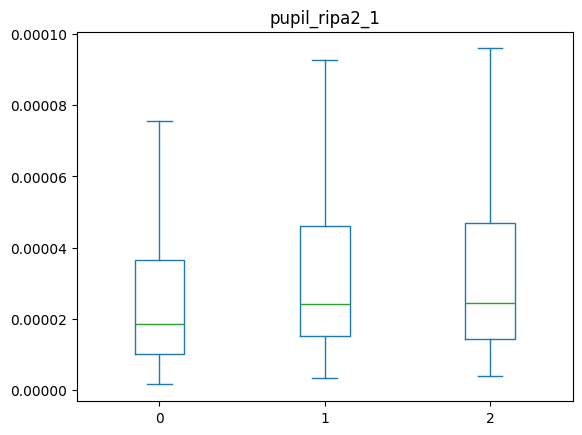

In [30]:
nback_features_df.plot(kind='box', column='pupil_ripa2_1', by='nback_level', showfliers=False)

<Axes: xlabel='timestamp_sec'>

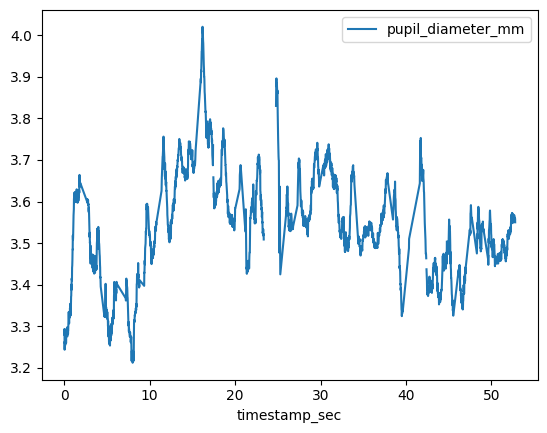

In [43]:
group_df = all_eye_data_grouped.get_group(('JCK0', 1, 1))
processed_df, gaze_df, pupil_df, gaps_df = cwpre.preprocess_nback_data(group_df, verbose=False, margins=200 / 1000)
processed_df.plot(x='timestamp_sec', y='pupil_diameter_mm')